In [30]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
# 展示高清图
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

In [32]:
# 制作数据集

# 设定数据预处理参数+数据增强
transform = transforms.Compose([
    transforms.Resize((64, 64)), #将图片格式统一设置为64x64
    transforms.RandomHorizontalFlip(p=0.5), #水平翻转
    transforms.RandomVerticalFlip(p=0.2), #上下翻转
    transforms.RandomRotation(degrees=10), # 旋转
    transforms.ToTensor(), #转换成张量
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #正则化
])

# 加载数据集
train_Data = datasets.ImageFolder(
    root = 'c:/Users/Christopher/Desktop/DL/dataset/train/', #数据集地址
    transform = transform
)
test_Data1 = datasets.ImageFolder(
    root = 'c:/Users/Christopher/Desktop/DL/dataset/test1/',
    transform = transform
)
test_Data2 = datasets.ImageFolder(
    root = 'c:/Users/Christopher/Desktop/DL/dataset/test2/',
    transform = transform
)

train_loader = DataLoader(train_Data, shuffle=True, batch_size=128) #封装数据，并且每次epoch都打乱顺序，返回128张照片
test1_loader  = DataLoader(test_Data1, shuffle=False, batch_size=128)#封装数据，并且每次epoch不打乱顺序，返回128张照片
test2_loader  = DataLoader(test_Data2, shuffle=False, batch_size=128)

In [33]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),nn.ReLU(),nn.BatchNorm2d(32), #（3，64，64）->(32,64,64)
            nn.MaxPool2d(kernel_size=2, stride=2), #(32,64,64)->(32,32,32)
            nn.Conv2d(32, 64, kernel_size=3, stride=1,padding=1),nn.ReLU(),nn.BatchNorm2d(64), #(32,32,32)->(64,32,32)
            nn.MaxPool2d(kernel_size=2, stride=2), #(64,32,32)->(64,16,16)
            nn.Conv2d(64, 128, kernel_size=3, stride=1,padding=1),nn.ReLU(),nn.BatchNorm2d(128), #(64,16,16)->(128,16,16)
            nn.MaxPool2d(kernel_size=2, stride=2),#(128,16,16)->(128,8,8)
            nn.Flatten(), #(128,8,8)->(1,8192)
            nn.Linear(8192, 512), nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, 3)
        )

    def forward(self, x):
        y = self.net(x)
        return y

In [34]:
model = CNN().to('cuda:0')    # 创建子类的实例，并搬到GPU上

In [35]:
# 损失函数的选择
loss_fn = nn.CrossEntropyLoss()

In [36]:
# 优化算法的选择
learning_rate = 0.0005    #设置学习率
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate,
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,#周期
    eta_min=1e-5 #最小学习率
)

第1-1次训练:                损失函数: 1.1413280963897705
第1-2次训练:                损失函数: 3.464506149291992
第1-3次训练:                损失函数: 1.75718355178833
第1-4次训练:                损失函数: 1.1833727359771729
第1-5次训练:                损失函数: 1.3860442638397217
第1-6次训练:                损失函数: 0.8980333805084229
第1-7次训练:                损失函数: 0.8833431005477905
第1-8次训练:                损失函数: 1.0199545621871948
第1-9次训练:                损失函数: 0.7752857208251953
第1-10次训练:                损失函数: 0.7342779636383057
第1-11次训练:                损失函数: 0.591264009475708
第2-1次训练:                损失函数: 0.8976160883903503
第2-2次训练:                损失函数: 0.9433878660202026
第2-3次训练:                损失函数: 0.6668105125427246
第2-4次训练:                损失函数: 0.45300906896591187
第2-5次训练:                损失函数: 0.4874357283115387
第2-6次训练:                损失函数: 0.4982558786869049
第2-7次训练:                损失函数: 0.5046467185020447
第2-8次训练:                损失函数: 0.46645843982696533
第2-9次训练:                损失函数: 0.5038924217224121
第2-10次训练:           

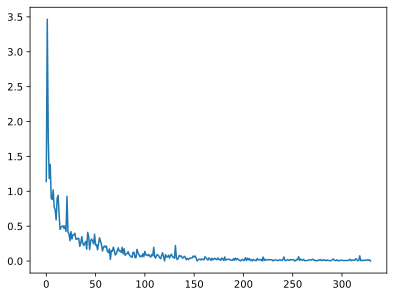

In [ ]:
epochs = 30
losses = []        # 记录损失函数变化的列表
i=0
for epoch in range(epochs):
    for (x, y) in train_loader:                  # 获取小批次的x与y
        x, y = x.to('cuda:0'), y.to('cuda:0')    # 把小批次搬到GPU上
        Pred = model(x)                          # 一次前向传播（小批量）
        loss = loss_fn(Pred, y)                  # 计算损失函数
        losses.append(loss.item())               # 记录损失函数的变化
        optimizer.zero_grad()                    # 清理上一轮滞留的梯度
        loss.backward()                          # 一次反向传播
        optimizer.step()                         # 优化内部参数
        i+=1
        print(f'第{epoch+1}-{i}次训练:                损失函数: {loss.item()}')
    i=0
    scheduler.step()# 更新学习率
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.show()

In [ ]:
# 测试网络
correct1 = 0
total1 = 0
correct2 = 0
total2 = 0
with torch.no_grad():                                   # 该局部关闭梯度计算功能
    for (x, y) in test1_loader:                          # 获取小批次的x与y
        x, y = x.to('cuda:0'), y.to('cuda:0')           # 把小批次搬到GPU上
        Pred = model(x)                                 # 一次前向传播（小批量）
        _, predicted = torch.max(Pred.data, dim=1) # 获取预测类别
        correct1 += torch.sum( (predicted == y) ) # 统计正确预测数
        total1 += y.size(0) 

with torch.no_grad():                                   
    for (x, y) in test2_loader:                          
        x, y = x.to('cuda:0'), y.to('cuda:0')           
        Pred = model(x)                                 
        _, predicted = torch.max(Pred.data, dim=1)
        correct2 += torch.sum( (predicted == y) )
        total2 += y.size(0) 

        
print(f'test1总体精准度：{100 * correct1/total1}% \n')
print(f'test2总体精准度：{100 * correct2/total2}% ')


test1总体精准度：94.02174377441406% 

test2总体精准度：92.14286041259766% 
